# Load the trained models

Loads the two models trained in `car_brand_predictor.ipynb` from `models/`, so nothing has to be retrained:
- **Small CNN**: trained from scratch on 128×128 images
- **EfficientNetB0**: pretrained on ImageNet, fine-tuned on 224×224 images (the final model)

Run the cells in order. Loading takes a few seconds.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # hide TensorFlow's startup messages

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from PIL import Image

DATA_DIR = Path("data")
MODELS_DIR = Path("models")

# Same brand order as during training: label 0 is the first brand alphabetically
class_names = sorted(pd.read_csv(DATA_DIR / "index.csv")["brand"].unique())
print(f"{len(class_names)} brands")

33 brands


## 1. Load the models and their training history

Each model is stored with its image size, because each one only accepts images of the size it was trained on.

In [2]:
models = {
    "Small CNN": (keras.models.load_model(MODELS_DIR / "small_cnn.keras"), 128),
    "EfficientNetB0": (keras.models.load_model(MODELS_DIR / "efficientnet_b0.keras"), 224),
}
histories = {
    "Small CNN": pd.read_csv(MODELS_DIR / "small_cnn_history.csv"),
    "EfficientNetB0": pd.read_csv(MODELS_DIR / "efficientnet_b0_history.csv"),
}

for name, (model, size) in models.items():
    best = histories[name]["val_accuracy"].max()
    print(f"{name}: {model.count_params():,} weights, {size}×{size} images, "
          f"{len(histories[name])} epochs, best validation accuracy {best:.1%}")

I0000 00:00:1790665300.744270 10964318 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1790665300.744404 10964318 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Small CNN: 1,588,481 weights, 128×128 images, 35 epochs, best validation accuracy 98.3%
EfficientNetB0: 4,091,844 weights, 224×224 images, 23 epochs, best validation accuracy 99.2%


## 2. Learning curves

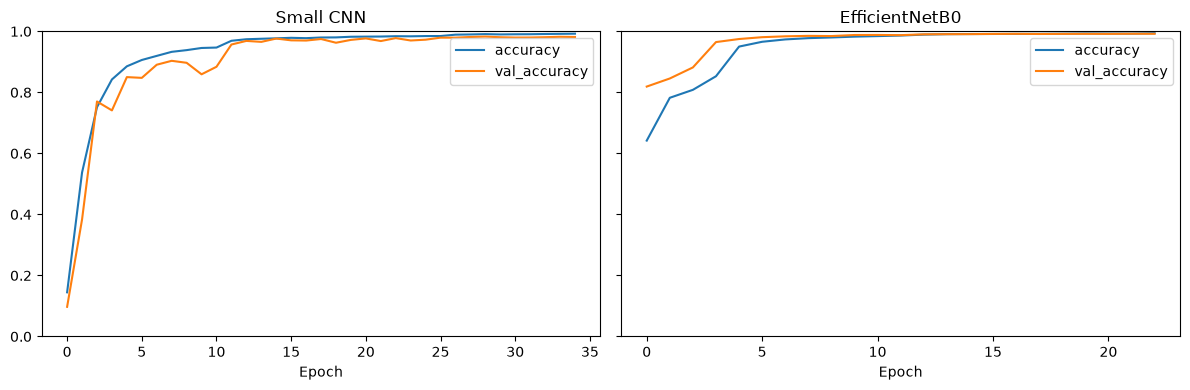

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (name, curves) in zip(axes, histories.items()):
    curves[["accuracy", "val_accuracy"]].plot(ax=ax, title=name)
    ax.set_xlabel("Epoch")
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 3. Final test score

`models/test_predictions.csv` holds EfficientNetB0's prediction for each of the 5,982 test photos, which the model never saw during training.

Test accuracy: 99.4%
Test balanced accuracy: 98.9%


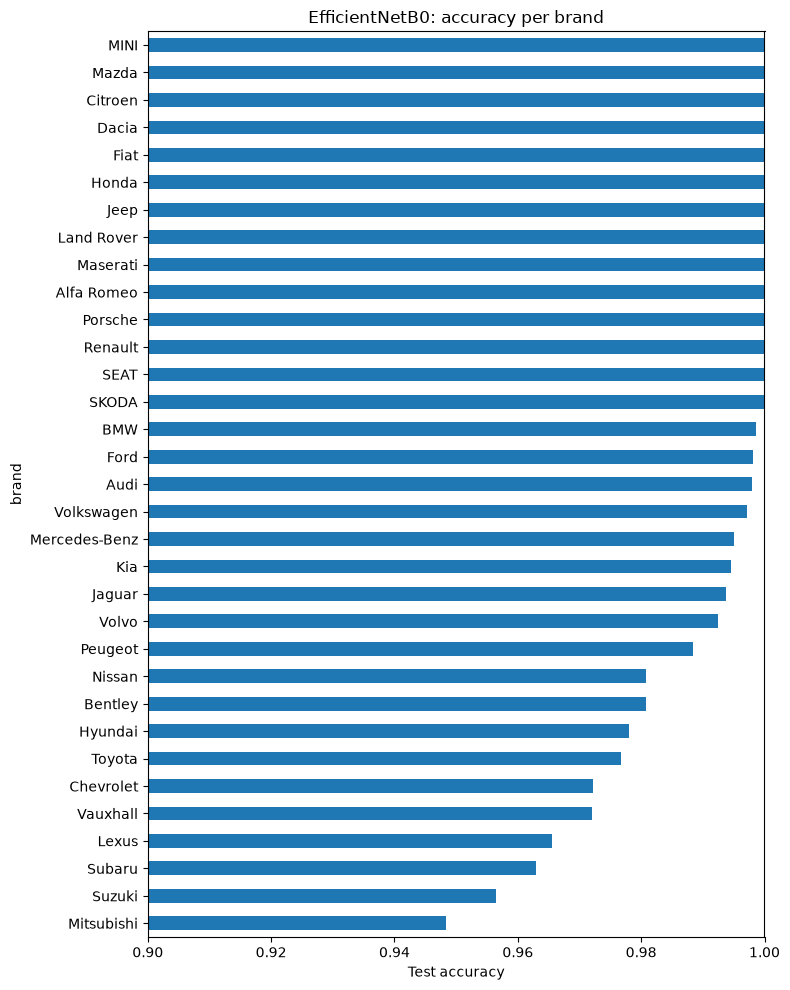

In [4]:
test = pd.read_csv(MODELS_DIR / "test_predictions.csv")
per_brand = test.groupby("brand")["correct"].mean().sort_values()

print(f"Test accuracy: {test['correct'].mean():.1%}")
print(f"Test balanced accuracy: {per_brand.mean():.1%}")

ax = per_brand.plot.barh(figsize=(8, 10))
ax.set_xlim(0.9, 1)
ax.set_xlabel("Test accuracy")
ax.set_title("EfficientNetB0: accuracy per brand")
plt.tight_layout()
plt.show()

## 4. Predict the brand of any photo

`predict_brand` loads a photo, resizes it to the model's size and returns the most likely brands. The model outputs one raw score per brand; softmax turns them into probabilities.

In [5]:
def predict_brand(path, model_name="EfficientNetB0", top=3):
    """Return the `top` most likely brands for one photo, with their probabilities."""
    model, size = models[model_name]
    image = tf.io.decode_image(tf.io.read_file(str(path)), channels=3, expand_animations=False)
    image = tf.image.resize(image, (size, size))
    scores = model.predict(image[None], verbose=0)[0]
    probabilities = tf.nn.softmax(scores).numpy()
    best = probabilities.argsort()[::-1][:top]
    return [(class_names[i], float(probabilities[i])) for i in best]


path = test["path"].iloc[0]
print(path)
for model_name in models:
    print(f"{model_name}: {predict_brand(path, model_name)}")

data/confirmed_fronts/Abarth/2015/Abarth$$595$$2015$$Blue$$2_4$$32$$image_2.jpg


Small CNN: [('Fiat', 0.9999996423721313), ('Suzuki', 2.0838866987560323e-07), ('Vauxhall', 1.526006343510744e-07)]


EfficientNetB0: [('Fiat', 0.999735414981842), ('Ford', 0.00015232633450068533), ('MINI', 5.22816480952315e-05)]


12 random test photos with the true brand and EfficientNetB0's top 3 guesses (green when the first guess is right). Change `random_state` to see others.

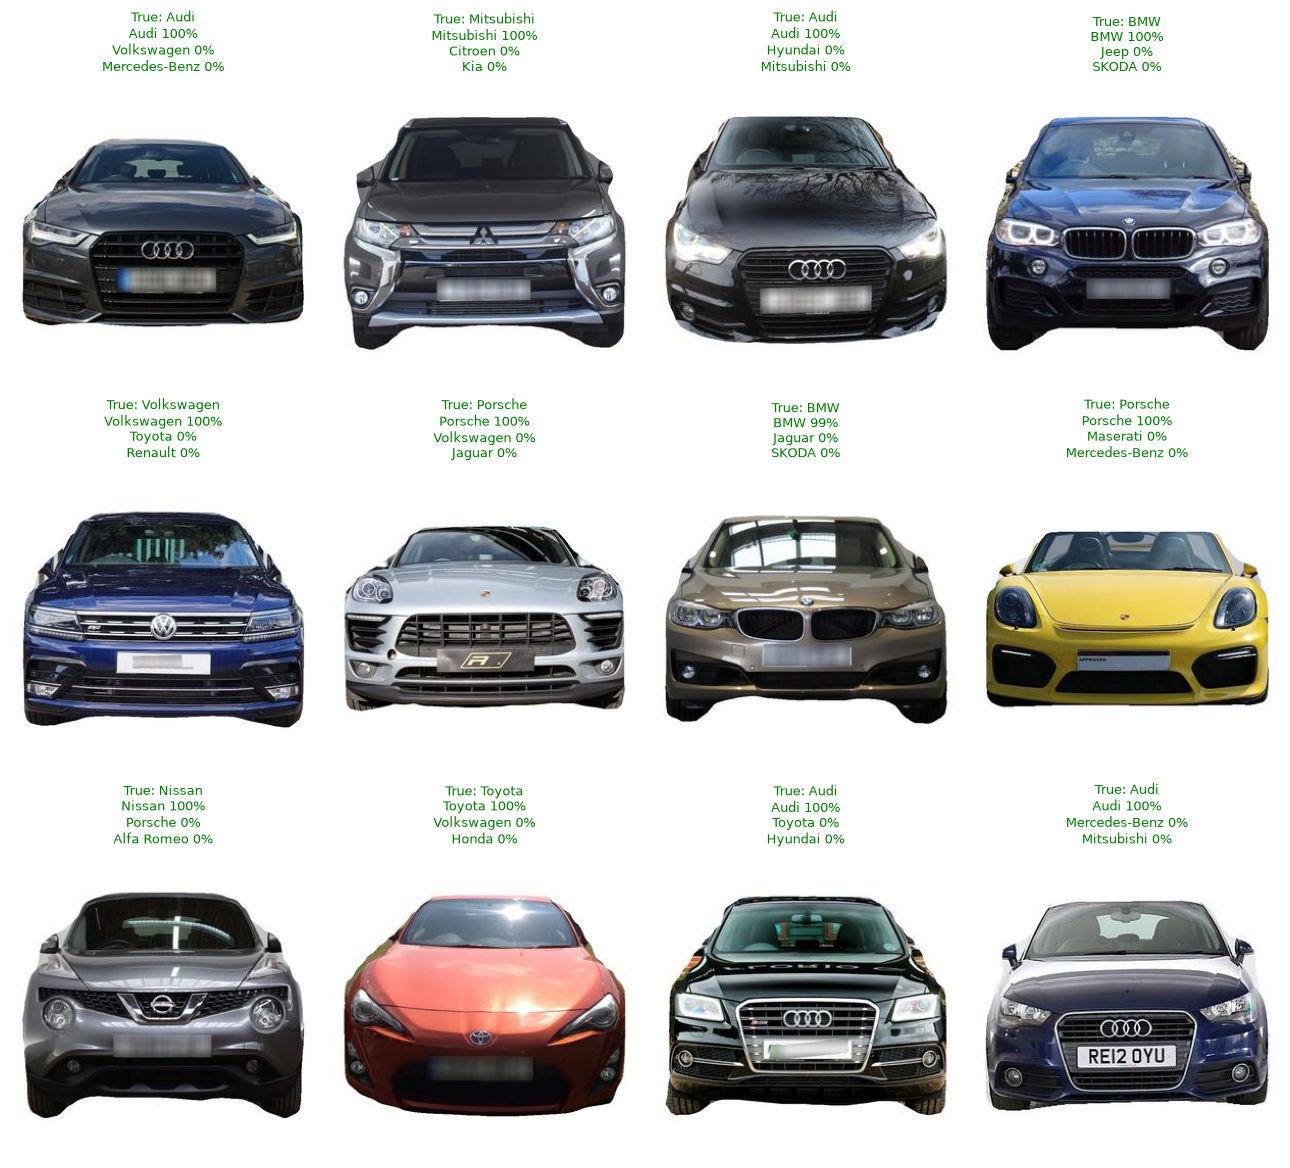

In [6]:
examples = test.sample(12, random_state=7)

fig, axes = plt.subplots(3, 4, figsize=(13, 12))
for ax, (_, row) in zip(axes.flat, examples.iterrows()):
    guesses = predict_brand(row["path"])
    ax.imshow(Image.open(row["path"]))
    ax.set_title(
        f"True: {row['brand']}\n" + "\n".join(f"{brand} {p:.0%}" for brand, p in guesses),
        fontsize=9,
        color="green" if guesses[0][0] == row["brand"] else "red",
    )
    ax.axis("off")
plt.tight_layout()
plt.show()

### Try your own photo

Put the path of a car-front photo (JPEG or PNG) below. The model works best on photos framed like the training data: the front of the car, filling most of the picture.

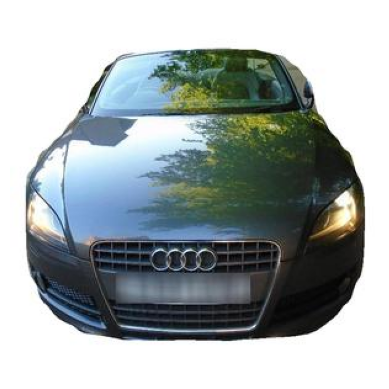

Audi: 100.0%
Land Rover: 0.0%
Lexus: 0.0%


In [7]:
my_photo = test["path"].iloc[100]  # replace with e.g. "my_car.jpg"

plt.imshow(Image.open(my_photo))
plt.axis("off")
plt.show()
for brand, p in predict_brand(my_photo):
    print(f"{brand}: {p:.1%}")